Financial News From Economic Times

In [4]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException, TimeoutException, StaleElementReferenceException, ElementClickInterceptedException
from webdriver_manager.chrome import ChromeDriverManager
import time

TARGET_URL = "https://economictimes.indiatimes.com/topic/nvidia"
OUTPUT_CSV_FILE = "nvidia_financial_news.csv"
TARGET_ARTICLE_COUNT = 200
MAX_CLICK_ATTEMPTS = 12

def setup_driver():
    options = webdriver.ChromeOptions()
    options.add_argument('--disable-gpu')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36')
    options.add_argument("--disable-notifications")
    options.add_argument("--disable-popup-blocking")

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=options)
    driver.implicitly_wait(3)
    driver.maximize_window()
    return driver

def scrape_financial_news(driver, url, target_count, max_clicks):
    scraped_data = []
    scraped_headlines = set()
    site_name = "The Economic Times"
    article_selector = "div.clr.flt.topicstry"
    last_article_index = 0

    try:
        driver.get(url)
        wait = WebDriverWait(driver, 15)

        try:
            cookie_button = WebDriverWait(driver, 5).until(EC.element_to_be_clickable(
                (By.XPATH, "//button[contains(text(), 'Accept') or contains(text(), 'Agree') or contains(@id, 'cookie') or contains(@class,'cookie-accept')]")
            ))
            cookie_button.click()
        except:
            pass
        wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, article_selector)))
        click_count = 0
        stale_retries = 0

        while len(scraped_data) < target_count and click_count < max_clicks:
            time.sleep(1)
            try:
                articles = driver.find_elements(By.CSS_SELECTOR, article_selector)

                for index in range(last_article_index, len(articles)):
                    article = articles[index]
                    if not article.is_displayed():
                        continue
                    try:
                        headline_element = article.find_element(By.CSS_SELECTOR,"div.contentD > a")
                        headline = headline_element.text.strip()
                    except NoSuchElementException:
                        continue
                    if not headline or headline in scraped_headlines:
                        continue
                    date_str = "Date not found" #Default if nothing is found
                    try:
                        date_element = article.find_element(By.CSS_SELECTOR, "div.contentD > time")
                        date_str = date_element.text.strip()
                    except NoSuchElementException:
                        pass

                    scraped_data.append({
                        'Source': site_name,
                        'company' : 'NVDA',
                        'Headline': headline,
                        'Date': date_str
                    })
                    scraped_headlines.add(headline)

                    if len(scraped_data) >= target_count:
                        break
                last_article_index = len(articles)
                if len(scraped_data) >= target_count:
                    break

                # Click "Load More"
                try:
                    articles_before_click = len(driver.find_elements(By.CSS_SELECTOR, article_selector))

                    load_more = WebDriverWait(driver, 10).until(EC.element_to_be_clickable((By.CSS_SELECTOR, "span.loadMore.jsTopicLoadMore")))

                    try:
                        load_more.click()
                    except ElementClickInterceptedException:
                        driver.excecute_script("arguments[0].click();", load_more)

                    click_count += 1

                    WebDriverWait(driver, 15).until(
                        lambda d: len(d.find_elements(By.CSS_SELECTOR, article_selector)) > articles_before_click
                    )
                    time.sleep(2)
                except(TimeoutException, ElementClickInterceptedException):
                    break
            except StaleElementReferenceException:
                stale_retries += 1
                if stale_retries < 3:
                    time.sleep(1)
                    continue
                else:
                    break
    except Exception:
        pass
    return scraped_data

if __name__ == "__main__":
    driver = setup_driver()
    scraped_articles = []

    if driver:
        try:
            scraped_articles = scrape_financial_news(
                driver, TARGET_URL, TARGET_ARTICLE_COUNT, MAX_CLICK_ATTEMPTS
            )
        finally:
            driver.quit()

    if scraped_articles:
        df = pd.DataFrame(scraped_articles)
        df['Headline'] = df['Headline'].str.strip()
        df['Date'] = df['Date'].str.strip()
        df.drop_duplicates(subset=['Headline'], keep='first', inplace=True)

        if len(df) > TARGET_ARTICLE_COUNT:
            df = df.head(TARGET_ARTICLE_COUNT)

        df.to_csv(OUTPUT_CSV_FILE, index=False, encoding='utf-8')


Finacial News From Financial Times

In [13]:
import csv
import time
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup

options = Options()
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36")
driver = webdriver.Chrome(options=options)

def parse_page(html):
    soup = BeautifulSoup(html, 'html.parser')
    articles = []
    company = 'AMZN'
    source = 'Financial Times'

    for item in soup.find_all('div', class_='o-teaser__content'):
        headline = item.find('div', class_='o-teaser__heading').text.strip() if item.find('div', class_='o-teaser__heading') else "N/A"
        date = item.find('time', class_='o-teaser__timestamp-date')['datetime'] if item.find('time', class_='o-teaser__timestamp-date') else "N/A"
        articles.append([source, company, headline, date])
    return articles

all_articles = []
base_url = "https://www.ft.com/search?q=amazon&page={page}&sort=relevance&isFirstView=true"

for page in range(1, 11):
    url = base_url.format(page=page)
    driver.get(url)
    time.sleep(2)
    all_articles.extend(parse_page(driver.page_source))

driver.quit()

with open("amazon_financial_news.csv", mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(["Source", "company", "Headline", "Date"])
    writer.writerows(all_articles)

print(f"Scraped {len(all_articles)} articles and saved to amazon_financial_news.csv")

Scraped 243 articles and saved to amazon_financial_news.csv


Phase - 1

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns


company_files = [
    'apple_financial_news.csv',
    'meta_financial_news.csv',
    'microsoft_financial_news.csv',
    'nvidia_financial_news.csv',
    'tesla_financial_news.csv'
]


raw_output_file = 'all_companies_news_raw.csv'
cleaned_output_file = 'all_companies_news_cleaned.csv'


print("--- Phase 1: Data Aggregation ---")

all_dataframes = []
total_rows_loaded = 0

for file in company_files:
    df_temp = pd.read_csv(file)
    expected_cols = ['Source', 'company', 'Headline', 'Date']
    if not all(col in df_temp.columns for col in expected_cols):
        continue
    if 'company' not in df_temp.columns:
        continue
    all_dataframes.append(df_temp)
    total_rows_loaded += len(df_temp)

if not all_dataframes:
    exit()

df_raw = pd.concat(all_dataframes, ignore_index=True)

print(f"\nCombined {len(all_dataframes)} files.")
print(f"Total rows aggregated: {len(df_raw)} (Expected around {total_rows_loaded})") # Check if concat worked as expected
print("Initial Data Overview (First 5 rows of raw data):")
print(df_raw.head())
print("\nInitial Data Info:")
df_raw.info()

try:
    df_raw.to_csv(raw_output_file, index=False)
    print(f"\nSuccessfully saved the combined raw dataset to {raw_output_file}")
except Exception as e:
    print(f"\nError saving raw data file {raw_output_file}: {e}")


# --- Phase 2: Data Cleaning and Preprocessing ---
print("\n--- Phase 2: Data Cleaning and Preprocessing ---")

df_cleaned = df_raw.copy()

print("\nChecking for missing values before cleaning:")
print(df_cleaned.isnull().sum())

initial_rows = len(df_cleaned)
df_cleaned.dropna(subset=['Headline', 'Date'], inplace=True)
rows_dropped = initial_rows - len(df_cleaned)
if rows_dropped > 0:
    print(f"Dropped {rows_dropped} rows due to missing Headline or Date.")


df_cleaned['Headline'] = df_cleaned['Headline'].astype(str)

print("\nParsing and cleaning 'Date' column...")
original_date_format = "%d %b, %Y, %I.%M %p IST" # Format from your example
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], format=original_date_format, errors='coerce')

# Check
nat_count = df_cleaned['Date'].isnull().sum()
if nat_count > 0:
    print(f"Warning: {nat_count} rows had invalid date formats and resulted in NaT.")
    initial_rows = len(df_cleaned)
    df_cleaned.dropna(subset=['Date'], inplace=True)
    print(f"Dropped {initial_rows - len(df_cleaned)} rows with NaT dates.")

# Sort by Date (important for time series analysis)
if not df_cleaned.empty:
    df_cleaned.sort_values(by='Date', inplace=True)
    print("DataFrame sorted by Date.")
    print(f"Date range in cleaned data: {df_cleaned['Date'].min()} to {df_cleaned['Date'].max()}")
else:
    print("DataFrame is empty after date cleaning. Cannot sort.")
    exit() # Exit if no valid data remains


print("\nCleaning 'Headline' text (lowercase, remove punctuation/numbers)...")

def clean_text_basic(text):
    """ Basic text cleaning: lowercase, remove punctuation/numbers, extra whitespace. """
    if not isinstance(text, str):
        return ""
    text = text.lower() # Lowercase
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace and strip ends
    return text

# Apply cleaning to a NEW column, keeping the original for sentiment analysis
df_cleaned['Cleaned_Headline'] = df_cleaned['Headline'].apply(clean_text_basic)

print("Created 'Cleaned_Headline' column. Examples:")
print(df_cleaned[['Headline', 'Cleaned_Headline']].head())

# 4. Check and Standardize 'company' Column
print("\nChecking 'company' column values...")
unique_companies = df_cleaned['company'].unique()
print(f"Unique company identifiers found: {unique_companies}")
# Add standardization here if needed (e.g., mapping variations to a standard ticker)
# Example: df_cleaned['company'] = df_cleaned['company'].replace({'NVDA': 'NVIDIA'})
# For now, assuming the tickers like 'NVDA', 'AAPL' are consistent.

# 5. Check 'Source' Column (Optional Standardization)
print("\nChecking 'Source' column values...")
unique_sources = df_cleaned['Source'].unique()
print(f"Unique sources found: {unique_sources}")
# Add standardization if needed (e.g., if 'The Economic Times' and 'Economic Times' both appear)
# Example: df_cleaned['Source'] = df_cleaned['Source'].replace({'Economic Times': 'The Economic Times'})

# 6. Handle Duplicate Entries
print("\nChecking for duplicate rows...")
initial_rows = len(df_cleaned)
# Define duplicates based on key columns (e.g., same headline, company, and date (ignoring time part))
df_cleaned['Date_Only'] = df_cleaned['Date'].dt.date # Create a date-only column for duplicate check
duplicates_subset = ['Date_Only', 'company', 'Headline'] # Use original headline for exact match
num_duplicates_before = df_cleaned.duplicated(subset=duplicates_subset).sum()
print(f"Found {num_duplicates_before} potential duplicate entries based on Date, Company, and Headline.")

df_cleaned.drop_duplicates(subset=duplicates_subset, keep='first', inplace=True)
rows_dropped = initial_rows - len(df_cleaned)
if rows_dropped > 0:
    print(f"Dropped {rows_dropped} duplicate rows, keeping the first occurrence.")

# Drop the temporary Date_Only column
df_cleaned.drop(columns=['Date_Only'], inplace=True)


# 7. Final Check of Cleaned Data
print("\n--- Final Cleaned Data Check ---")
print(f"Total rows in cleaned dataset: {len(df_cleaned)}")
print("\nCleaned Data Info:")
df_cleaned.info()
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum()) # Should ideally be zero for key columns now
print("\nCleaned Data Overview (First 5 rows):")
print(df_cleaned.head())
print("\nCleaned Data Overview (Last 5 rows):")
print(df_cleaned.tail())

# 8. Save the Cleaned Dataset
# Select columns to save (keeping it tidy)
columns_to_save = ['Source', 'company', 'Headline', 'Date', 'Cleaned_Headline']
# Ensure all selected columns exist before saving
existing_columns = [col for col in columns_to_save if col in df_cleaned.columns]

if len(existing_columns) != len(columns_to_save):
    print("\nWarning: Not all desired columns exist in the final cleaned DataFrame.")
    print(f"Columns that will be saved: {existing_columns}")

try:
    df_cleaned[existing_columns].to_csv(cleaned_output_file, index=False, date_format='%Y-%m-%d %H:%M:%S') # Standard date format
    print(f"\nSuccessfully saved the cleaned dataset ({len(df_cleaned)} rows) to {cleaned_output_file}")
except Exception as e:
    print(f"\nError saving cleaned data file {cleaned_output_file}: {e}")



--- Phase 1: Data Aggregation ---
Successfully loaded 200 rows from apple_financial_news.csv
Successfully loaded 200 rows from meta_financial_news.csv
Successfully loaded 200 rows from microsoft_financial_news.csv
Successfully loaded 200 rows from nvidia_financial_news.csv
Successfully loaded 200 rows from tesla_financial_news.csv

Combined 5 files.
Total rows aggregated: 1000 (Expected around 1000)
Initial Data Overview (First 5 rows of raw data):
               Source company  \
0  The Economic Times    AAPL   
1  The Economic Times    AAPL   
2  The Economic Times    AAPL   
3  The Economic Times    AAPL   
4  The Economic Times    AAPL   

                                            Headline  \
0  Are you charging your iPhone wrong? Apple says...   
1  Apple's logo has no connection with byte, Bibl...   
2  What is M3 Ultra? Learn about Apple’s new sili...   
3  Apple launches new iPad Air upgraded with the ...   
4  Top 5 camera smartphones to capture your happi...   

           

Phase-2

NLTK resources checked/downloaded.
Lemmatizer, Stopwords, and VADER Analyzer initialized.

--- Loading Cleaned Data ---
Successfully loaded cleaned data from all_companies_news_cleaned.csv

Cleaned Data Overview:
               Source company  \
0  The Economic Times    MSFT   
1  The Economic Times    MSFT   
2  The Economic Times    MSFT   
3  The Economic Times    MSFT   
4  The Economic Times    MSFT   

                                            Headline                Date  \
0  German competition watchdog vows closer eye on... 2024-10-01 14:02:00   
1  Infosys, Microsoft expand partnership to boost... 2024-10-09 19:47:00   
2    Microsoft's VP of GenAI research to join OpenAI 2024-10-15 08:33:00   
3     Microsoft and OpenAI 'bromance' begins to fray 2024-10-19 15:50:00   
4  Microsoft's AI demand under scrutiny as invest... 2024-10-28 16:17:00   

                                    Cleaned_Headline  
0  german competition watchdog vows closer eye on...  
1  infosys microsoft 

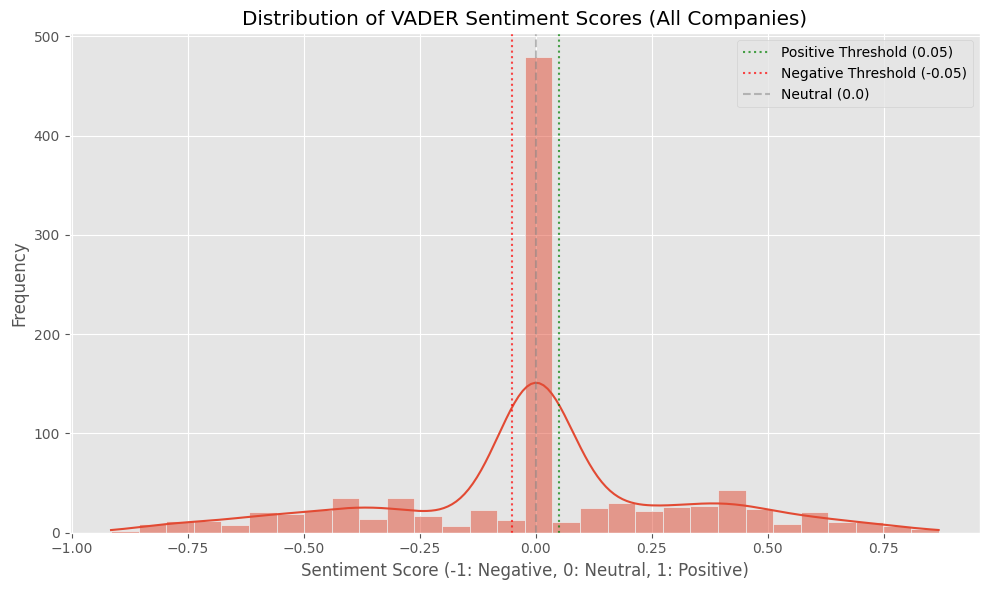

C:\Users\HP\AppData\Local\Temp\ipykernel_4740\1585839855.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sentiment_Category', data=df, order=present_categories, palette='viridis')


Saved VADER sentiment category count plot (overall).


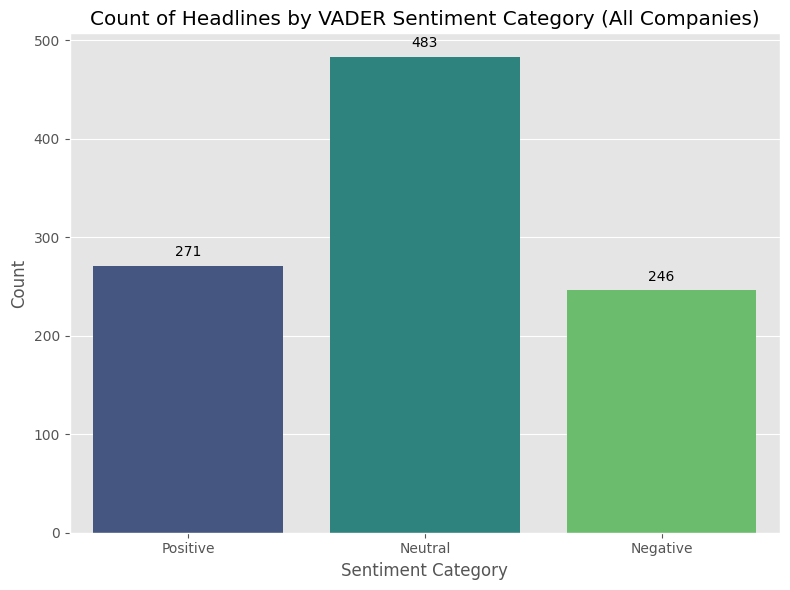

Saved VADER sentiment trend plot (overall average).


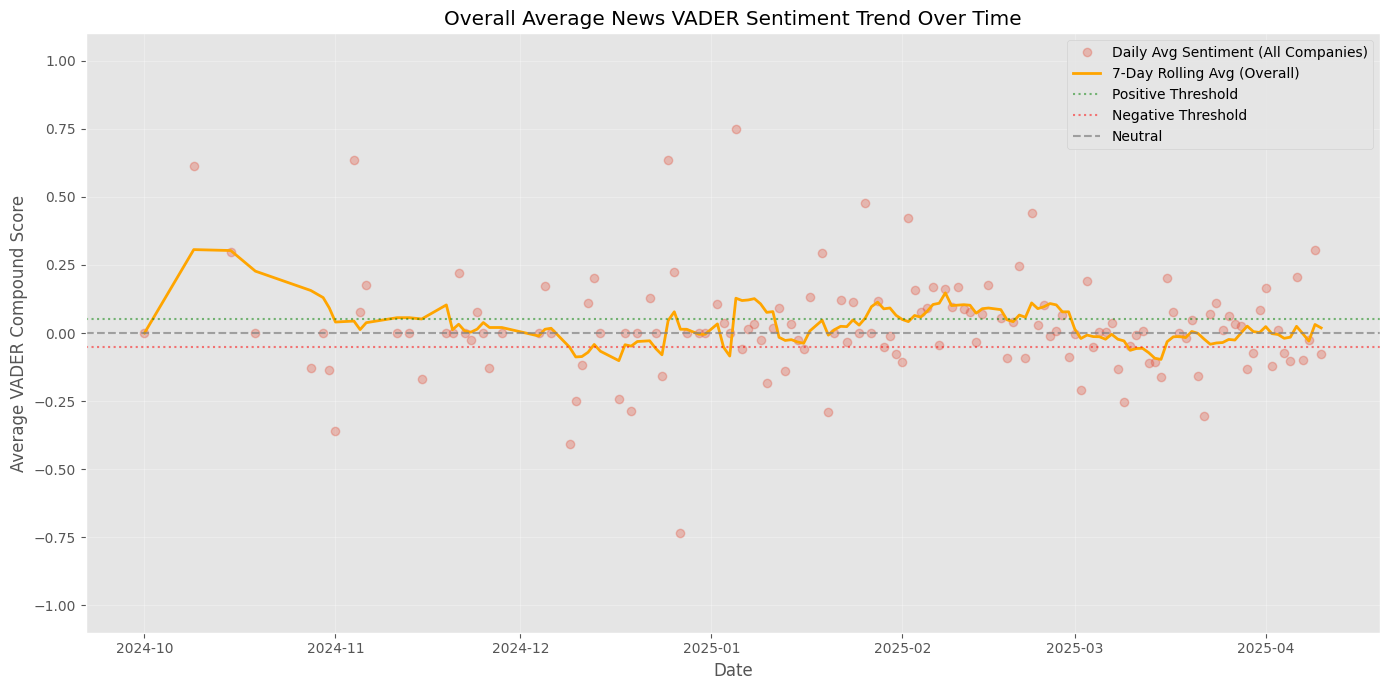

C:\Users\HP\AppData\Local\Temp\ipykernel_4740\1585839855.py:269: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='company', y='Sentiment_Score', data=df, order=company_order, palette='Set2')


Saved VADER sentiment boxplot by company.


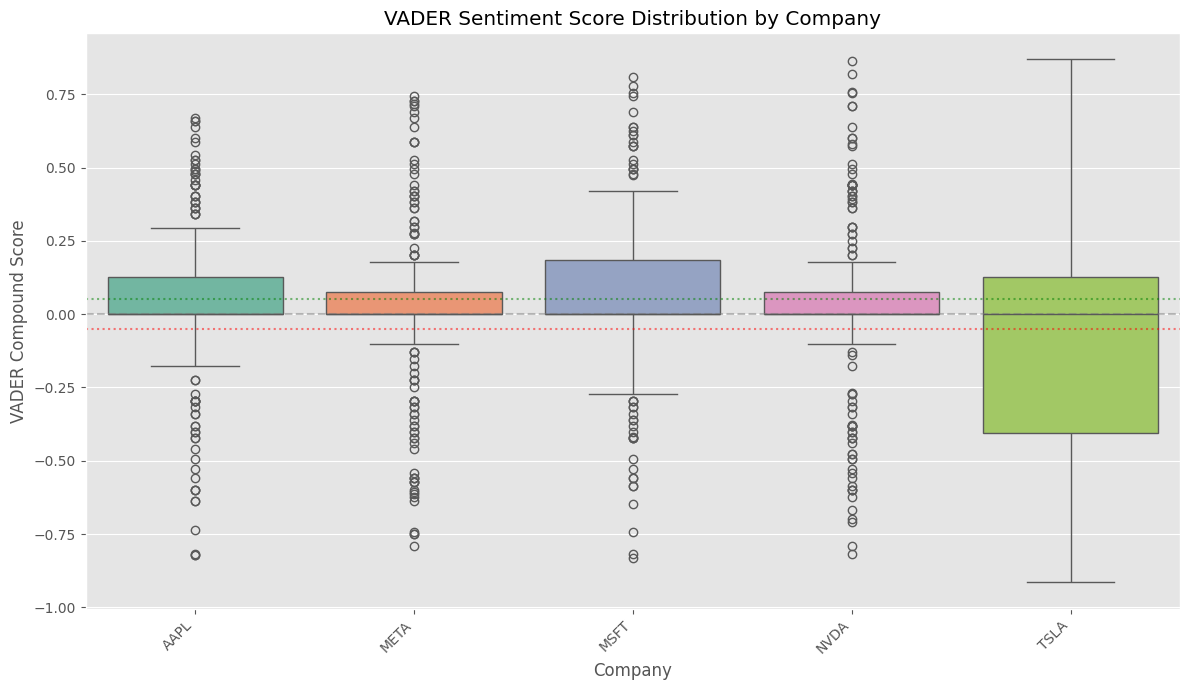

Saved VADER sentiment countplot by company.


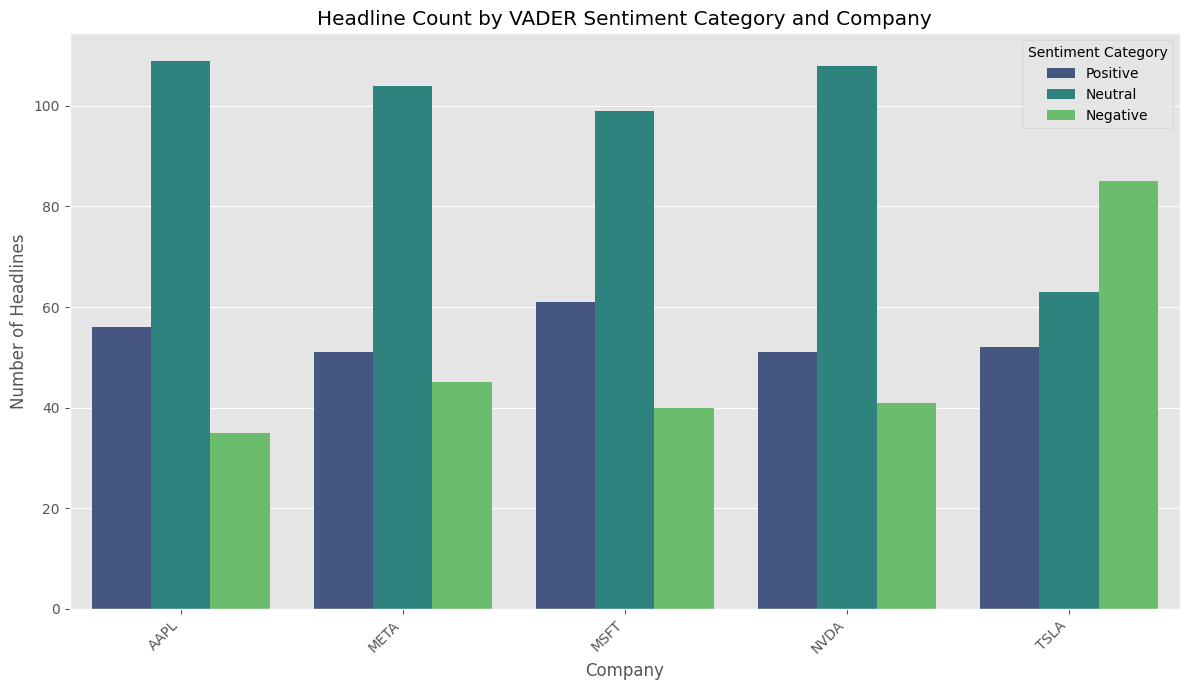


--- Analysis Results (Using VADER) ---

Top 5 Most Positive Headlines (Overall):
1. [TSLA] Elon Musk doing a great job! Donald Trump plans to buy a Tesla to save Musk's 'baby' as cos shares plummet (Score: 0.8687)
2. [TSLA] Tesla is back! Stock surges as Elon Musk reasserts control, surprise all-hands meeting signals bold moves, boosting investor confidence (Score: 0.8655)
3. [NVDA] U.S. stock market today: Markets surge – Dow Jumps 500 points, S&P 500 gains 1.5%, Nasdaq rises 1.8% as Trump’s tariff flexibility boosts investor optimism – Here’s what to watch next (Score: 0.8625)
4. [NVDA] US stock market today: Nvidia, Apple, Tesla, Microsoft, Alphabet share prices soar as 'Magnificent Seven' to add more than $1 trillion in value (Score: 0.8176)
5. [MSFT] Nordics' efficient energy infrastructure ideal for Microsoft's data centre expansion (Score: 0.8074)

Top 5 Most Negative Headlines (Overall):
1. [TSLA] Tesla sparks outrage in Germany as reports claim workers on sick leave denied pa

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


print("Downloading NLTK resources (if needed)...")
nltk.data.find('sentiment/vader_lexicon.zip')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
print("NLTK resources checked/downloaded.")

.
lemmatizer = WordNetLemmatizer()
analyzer = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

file_path = 'all_companies_news_cleaned.csv'
output_file = 'all_companies_news_with_sentiment.csv'

df = pd.read_csv(file_path, parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.dropna(subset=['Headline', 'Date', 'company'], inplace=True)
df['Headline'] = df['Headline'].astype(str)

def clean_text_basic(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'[\W]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_vader_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    scores = analyzer.polarity_scores(text)
    return scores['compound']

start_time = time.time()
df['Sentiment_Score'] = df['Headline'].apply(get_vader_sentiment)
end_time = time.time()

def categorize_vader_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment_Category'] = df['Sentiment_Score'].apply(categorize_vader_sentiment)
company_sentiment_counts = df.groupby('company')['Sentiment_Category'].value_counts(normalize=True).unstack(fill_value=0) * 100
if not df.empty and 'Sentiment_Score' in df.columns:
    plt.style.use('ggplot')
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Sentiment_Score'], kde=True, bins=30)
    plt.title('Distribution of VADER Sentiment Scores (All Companies)')
    plt.xlabel('Sentiment Score (-1: Negative, 0: Neutral, 1: Positive)')
    plt.ylabel('Frequency')
    plt.axvline(x=0.05, color='green', linestyle=':', alpha=0.7, label='Positive Threshold (0.05)')
    plt.axvline(x=-0.05, color='red', linestyle=':', alpha=0.7, label='Negative Threshold (-0.05)')
    plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5, label='Neutral (0.0)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('vader_sentiment_distribution_overall.png')
    plt.show()
    plt.figure(figsize=(8, 6))
    category_order = ['Positive', 'Neutral', 'Negative']
    present_categories = [cat for cat in category_order if cat in df['Sentiment_Category'].unique()]
    if present_categories:
        ax = sns.countplot(x='Sentiment_Category', data=df, order=present_categories, palette='viridis')
        plt.title('Count of Headlines by VADER Sentiment Category (All Companies)')
        plt.xlabel('Sentiment Category')
        plt.ylabel('Count')
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
        plt.tight_layout()
        plt.savefig('vader_sentiment_category_counts_overall.png')
        plt.show()
    plt.figure(figsize=(14, 7))
    daily_avg_sentiment = df.groupby(df['Date'].dt.date)['Sentiment_Score'].mean()
    rolling_avg = daily_avg_sentiment.rolling(window=7, min_periods=1).mean()
    plt.plot(daily_avg_sentiment.index, daily_avg_sentiment.values, marker='o', linestyle='', alpha=0.3, label='Daily Avg Sentiment (All Companies)')
    plt.plot(rolling_avg.index, rolling_avg.values, linestyle='-', color='orange', linewidth=2, label='7-Day Rolling Avg (Overall)')
    plt.title('Overall Average News VADER Sentiment Trend Over Time')
    plt.xlabel('Date')
    plt.ylabel('Average VADER Compound Score')
    plt.axhline(y=0.05, color='green', linestyle=':', alpha=0.5, label='Positive Threshold')
    plt.axhline(y=-0.05, color='red', linestyle=':', alpha=0.5, label='Negative Threshold')
    plt.axhline(y=0, color='grey', linestyle='--', alpha=0.7, label='Neutral')
    plt.ylim(-1.1, 1.1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('vader_sentiment_trend_overall.png')
    plt.show()
    plt.figure(figsize=(12, 7))
    company_order = sorted(df['company'].unique())
    sns.boxplot(x='company', y='Sentiment_Score', data=df, order=company_order, palette='Set2')
    plt.title('VADER Sentiment Score Distribution by Company')
    plt.xlabel('Company')
    plt.ylabel('VADER Compound Score')
    plt.axhline(y=0.05, color='green', linestyle=':', alpha=0.5)
    plt.axhline(y=-0.05, color='red', linestyle=':', alpha=0.5)
    plt.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('vader_sentiment_boxplot_by_company.png')
    plt.show()
    plt.figure(figsize=(12, 7))
    sns.countplot(x='company', hue='Sentiment_Category', data=df, order=company_order, hue_order=category_order, palette='viridis')
    plt.title('Headline Count by VADER Sentiment Category and Company')
    plt.xlabel('Company')
    plt.ylabel('Number of Headlines')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Sentiment Category')
    plt.tight_layout()
    plt.savefig('vader_sentiment_countplot_by_company.png')
    plt.show()


Phase - 4

[**********************80%*************          ]  4 of 5 completed

--- Loading Sentiment Data from all_companies_news_with_sentiment.csv ---
Successfully loaded 1000 rows.

--- Fetching Stock Market Data ---
Fetching stock data for tickers: AAPL, META, MSFT, NVDA, TSLA
Required date range (with buffer): 2024-09-30 to 2025-04-12


[*********************100%***********************]  5 of 5 completed
C:\Users\HP\AppData\Local\Temp\ipykernel_4740\1029639825.py:51: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stock_data_processed = stock_data_raw.stack(level=1).rename_axis(['Date', 'Ticker']).reset_index()
C:\Users\HP\AppData\Local\Temp\ipykernel_4740\1029639825.py:164: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) i

Stock data downloaded successfully.
DEBUG: Data has MultiIndex columns, processing...

--- Preparing Stock Data ---

DEBUG: Columns in stock_data_filtered (BEFORE rename):
Index(['Date', 'company', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

DEBUG: Columns in stock_data_filtered (AFTER lowercase):
Index(['date', 'company', 'close', 'high', 'low', 'open', 'volume'], dtype='object', name='Price')
DEBUG: Actual rename map being applied: {'close': 'adj_close', 'volume': 'stock_volume'}

DEBUG: Columns in stock_data_filtered (AFTER final rename):
Index(['date', 'company', 'adj_close', 'high', 'low', 'open', 'stock_volume'], dtype='object', name='Price')

Calculating daily returns...

DEBUG: Columns available for final selection: ['date', 'company', 'adj_close', 'high', 'low', 'open', 'stock_volume', 'stock_return', 'next_day_stock_return']
DEBUG: Will select columns: ['date', 'company', 'adj_close', 'open', 'high', 'low', 'stock_volume', 'stock_return', 'next_d

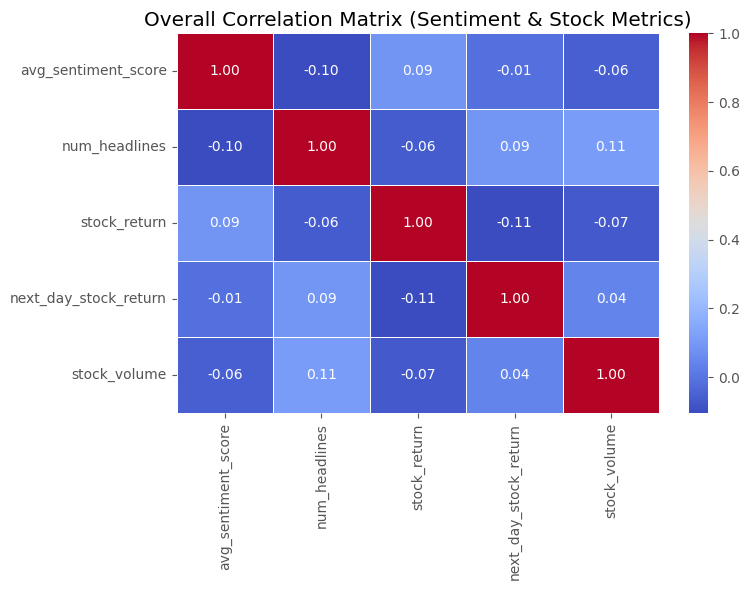


--- Correlation Analysis Per Company ---

--- AAPL ---
Correlation Matrix for AAPL:
                       avg_sentiment_score  num_headlines  stock_return  \
avg_sentiment_score                  1.000         -0.119         0.162   
num_headlines                       -0.119          1.000        -0.288   
stock_return                         0.162         -0.288         1.000   
next_day_stock_return               -0.105         -0.268         0.081   
stock_volume                        -0.201          0.312        -0.412   

                       next_day_stock_return  stock_volume  
avg_sentiment_score                   -0.105        -0.201  
num_headlines                         -0.268         0.312  
stock_return                           0.081        -0.412  
next_day_stock_return                  1.000         0.029  
stock_volume                           0.029         1.000  
Correlation (Sentiment vs Today's Return) for AAPL: 0.162 (p-value: 0.242)
Correlation (Sentiment 

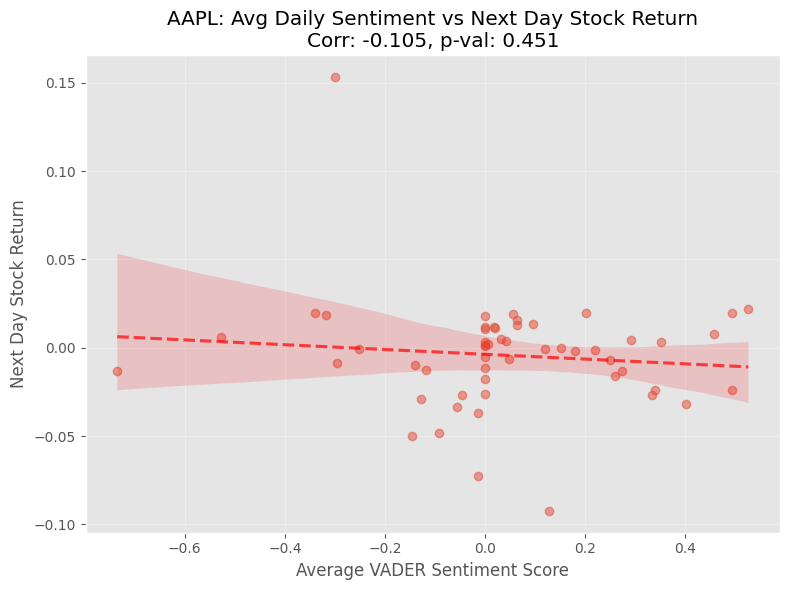


--- META ---
Correlation Matrix for META:
                       avg_sentiment_score  num_headlines  stock_return  \
avg_sentiment_score                  1.000         -0.158         0.208   
num_headlines                       -0.158          1.000        -0.125   
stock_return                         0.208         -0.125         1.000   
next_day_stock_return               -0.113          0.081        -0.145   
stock_volume                         0.169          0.059         0.040   

                       next_day_stock_return  stock_volume  
avg_sentiment_score                   -0.113         0.169  
num_headlines                          0.081         0.059  
stock_return                          -0.145         0.040  
next_day_stock_return                  1.000         0.044  
stock_volume                           0.044         1.000  
Correlation (Sentiment vs Today's Return) for META: 0.208 (p-value: 0.091)
Correlation (Sentiment vs Next Day's Return) for META: -0.113 (p-

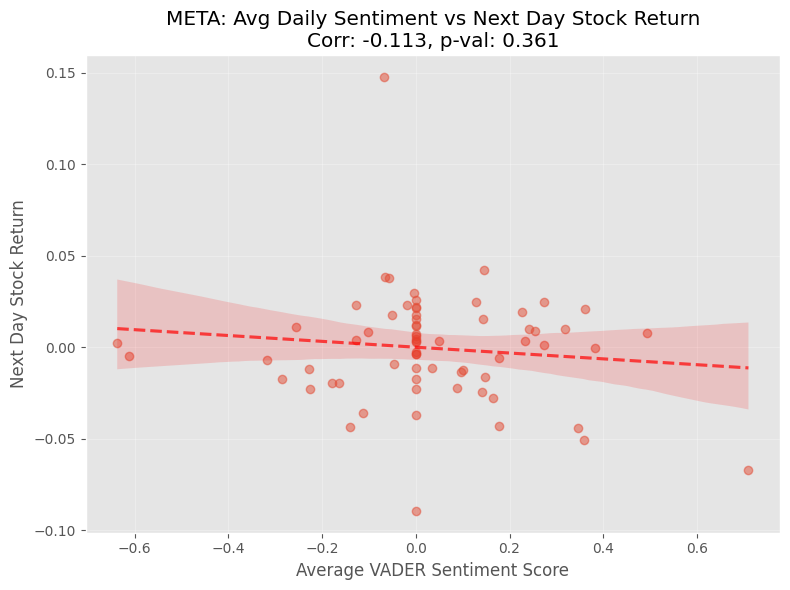


--- MSFT ---
Correlation Matrix for MSFT:
                       avg_sentiment_score  num_headlines  stock_return  \
avg_sentiment_score                  1.000         -0.046         0.119   
num_headlines                       -0.046          1.000        -0.211   
stock_return                         0.119         -0.211         1.000   
next_day_stock_return               -0.009         -0.241        -0.072   
stock_volume                        -0.183          0.305        -0.411   

                       next_day_stock_return  stock_volume  
avg_sentiment_score                   -0.009        -0.183  
num_headlines                         -0.241         0.305  
stock_return                          -0.072        -0.411  
next_day_stock_return                  1.000         0.080  
stock_volume                           0.080         1.000  
Correlation (Sentiment vs Today's Return) for MSFT: 0.119 (p-value: 0.295)
Correlation (Sentiment vs Next Day's Return) for MSFT: -0.009 (p-

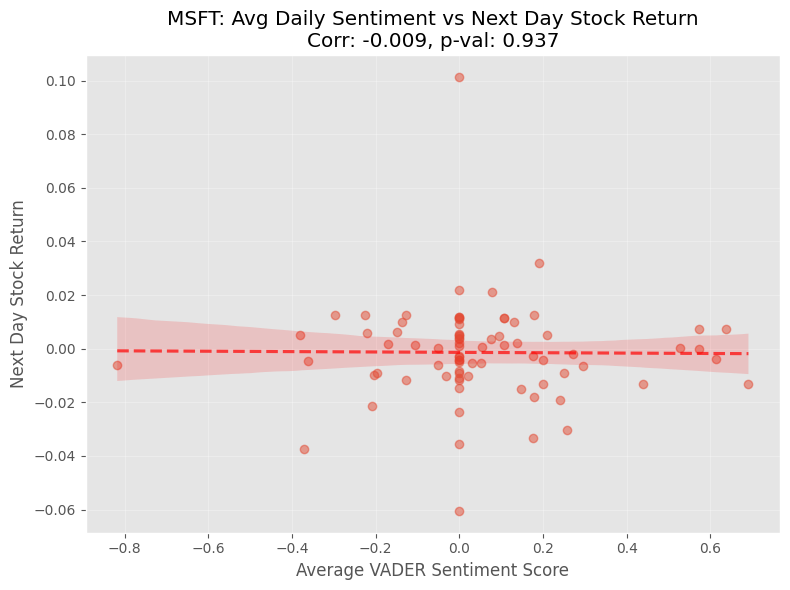


--- NVDA ---
Correlation Matrix for NVDA:
                       avg_sentiment_score  num_headlines  stock_return  \
avg_sentiment_score                  1.000          0.104         0.080   
num_headlines                        0.104          1.000        -0.012   
stock_return                         0.080         -0.012         1.000   
next_day_stock_return                0.029          0.047        -0.223   
stock_volume                         0.091          0.207        -0.158   

                       next_day_stock_return  stock_volume  
avg_sentiment_score                    0.029         0.091  
num_headlines                          0.047         0.207  
stock_return                          -0.223        -0.158  
next_day_stock_return                  1.000         0.200  
stock_volume                           0.200         1.000  
Correlation (Sentiment vs Today's Return) for NVDA: 0.080 (p-value: 0.500)
Correlation (Sentiment vs Next Day's Return) for NVDA: 0.029 (p-v

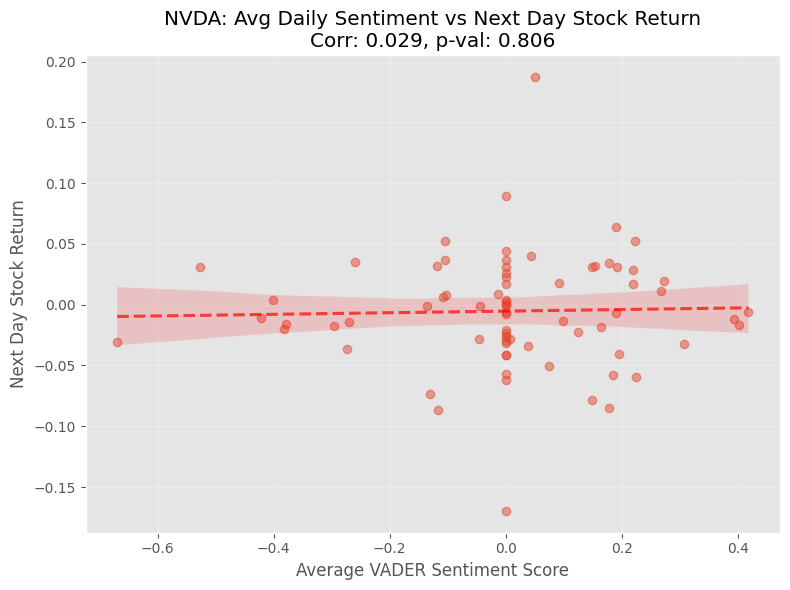


--- TSLA ---
Correlation Matrix for TSLA:
                       avg_sentiment_score  num_headlines  stock_return  \
avg_sentiment_score                  1.000         -0.173        -0.054   
num_headlines                       -0.173          1.000         0.076   
stock_return                        -0.054          0.076         1.000   
next_day_stock_return                0.070          0.400        -0.018   
stock_volume                        -0.137          0.644        -0.072   

                       next_day_stock_return  stock_volume  
avg_sentiment_score                    0.070        -0.137  
num_headlines                          0.400         0.644  
stock_return                          -0.018        -0.072  
next_day_stock_return                  1.000         0.198  
stock_volume                           0.198         1.000  
Correlation (Sentiment vs Today's Return) for TSLA: -0.054 (p-value: 0.735)
Correlation (Sentiment vs Next Day's Return) for TSLA: 0.070 (p-

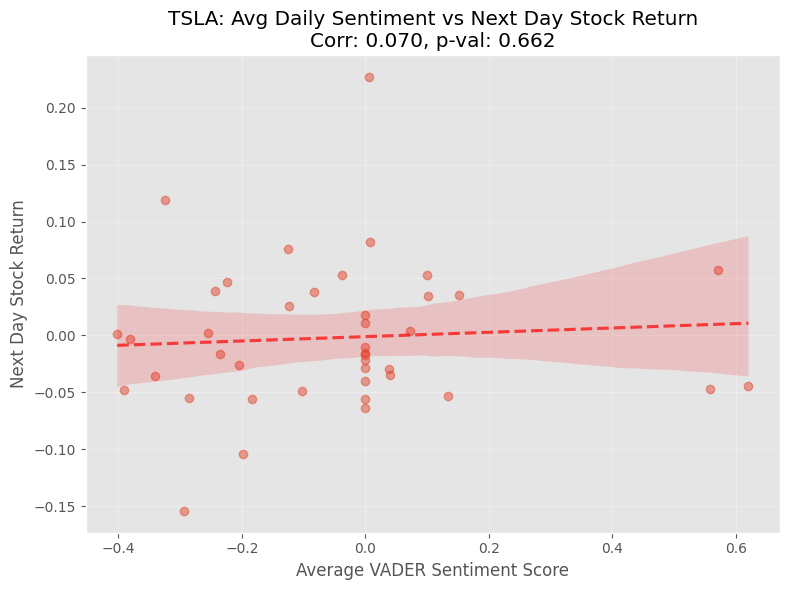


--- Interpretation Notes (Example - Add Your Own Analysis) ---
1. Review the correlation matrices (overall and per company). Look for correlations between 'avg_sentiment_score' and 'stock_return'/'next_day_stock_return'.
2. Pay attention to the signs (+/-) and magnitudes of the correlations.
3. Check the p-values calculated using pearsonr. A low p-value (e.g., < 0.05) suggests the correlation is statistically significant (less likely due to random chance).
4. The 'next_day_stock_return' correlation is often more interesting as it hints at predictive power (does today's news sentiment influence tomorrow's price?).
5. Note differences between companies. Some might show stronger correlations than others.
6. Remember: Correlation does not imply causation! News sentiment is just one factor affecting stock prices.
7. Consider the limitations: Daily aggregation might smooth out important intraday news effects. VADER is a good but not perfect sentiment tool. Market conditions change.

--- Sto

In [ ]:


import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings


warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.core.frame")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.core.arrays.masked")

# --- Configuration ---
sentiment_input_file = 'all_companies_news_with_sentiment.csv'
merged_output_file = 'merged_sentiment_stock_data_v4.csv'
tickers = ['AAPL', 'META', 'MSFT', 'NVDA', 'TSLA']


print(f"--- Loading Sentiment Data from {sentiment_input_file} ---")
try:
    df_sentiment = pd.read_csv(sentiment_input_file, parse_dates=['Date'])
    print(f"Successfully loaded {len(df_sentiment)} rows.")
except FileNotFoundError:
    print(f"Error: File not found at {sentiment_input_file}. Please run the previous sentiment analysis script.")
    exit()
except Exception as e:
    print(f"Error loading sentiment data: {e}")
    exit()
if df_sentiment.empty: print("Sentiment data is empty. Exiting."); exit()


print("\n--- Fetching Stock Market Data ---")
min_date = df_sentiment['Date'].min().strftime('%Y-%m-%d')
max_date = df_sentiment['Date'].max().strftime('%Y-%m-%d')
start_date = (df_sentiment['Date'].min() - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
end_date = (df_sentiment['Date'].max() + pd.Timedelta(days=2)).strftime('%Y-%m-%d')
print(f"Fetching stock data for tickers: {', '.join(tickers)}")
print(f"Required date range (with buffer): {start_date} to {end_date}")
try:
    # Download stock data
    stock_data_raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True) # auto_adjust=True handles Adj Close implicitly
    if stock_data_raw.empty: print("Error: No stock data downloaded."); exit()
    print("Stock data downloaded successfully.")


    if isinstance(stock_data_raw.columns, pd.MultiIndex):
        print("DEBUG: Data has MultiIndex columns, processing...")

        stock_data_processed = stock_data_raw.stack(level=1).rename_axis(['Date', 'Ticker']).reset_index()
    else:
        print("DEBUG: Data seems to be single index already.")
        stock_data_processed = stock_data_raw.reset_index() # Assuming Date is index

except Exception as e:
    print(f"Error downloading/processing stock data: {e}")
    exit()


print("\n--- Preparing Stock Data ---")


if 'Ticker' in stock_data_processed.columns:
    stock_data_filtered = stock_data_processed[stock_data_processed['Ticker'].str.upper().isin(tickers)].copy()
    stock_data_filtered = stock_data_filtered.rename(columns={'Ticker': 'company'})
else:

    print("DEBUG: 'Ticker' column not found, assuming single ticker or unexpected format.")
    stock_data_filtered = stock_data_processed.copy()
    
    if len(tickers) == 1 and 'company' not in stock_data_filtered.columns:
        stock_data_filtered['company'] = tickers[0]
    elif 'company' not in stock_data_filtered.columns:
         print("ERROR: Cannot determine company/ticker.")
         exit()

# >>> DEBUG: Print columns *before* rename <<<
print("\nDEBUG: Columns in stock_data_filtered (BEFORE rename):")
print(stock_data_filtered.columns)
# print("DEBUG: Sample data BEFORE rename:")
# print(stock_data_filtered.head())

# Standardize column names to lowercase for easier handling
stock_data_filtered.columns = stock_data_filtered.columns.str.lower()

# >>> DEBUG: Print columns *after* lowercase conversion <<<
print("\nDEBUG: Columns in stock_data_filtered (AFTER lowercase):")
print(stock_data_filtered.columns)


# Define the essential price column. Since auto_adjust=True, 'Close' is the adjusted close.
price_col = 'close'
# Rename columns for clarity and consistency (using lowercase names now)
rename_map = {
    price_col: 'adj_close', # Rename the adjusted close price column
    'volume': 'stock_volume'
}
# Check which columns from map exist before renaming
actual_rename_map = {k: v for k, v in rename_map.items() if k in stock_data_filtered.columns}
print(f"DEBUG: Actual rename map being applied: {actual_rename_map}")
stock_data_filtered = stock_data_filtered.rename(columns=actual_rename_map)


# >>> DEBUG: Print columns *after* rename <<<
print("\nDEBUG: Columns in stock_data_filtered (AFTER final rename):")
print(stock_data_filtered.columns)
# print("DEBUG: Sample data AFTER final rename:")
# print(stock_data_filtered.head())


# Sort by company and date for correct return calculation
if 'company' not in stock_data_filtered.columns: print("ERROR: 'company' column missing before sorting/grouping!"); exit()
if 'date' not in stock_data_filtered.columns: print("ERROR: 'date' column missing before sorting/grouping!"); exit()
stock_data_filtered = stock_data_filtered.sort_values(['company', 'date'])

# Calculate Daily Percentage Returns PER COMPANY
# Check if 'adj_close' exists NOW
if 'adj_close' not in stock_data_filtered.columns:
     print("ERROR: 'adj_close' column missing before pct_change calculation!")
     print(f"DEBUG: Columns available right before pct_change: {stock_data_filtered.columns.tolist()}")
     exit()

print("\nCalculating daily returns...")
stock_data_filtered['stock_return'] = stock_data_filtered.groupby('company')['adj_close'].pct_change().fillna(0)

# Calculate Next Day's Return PER COMPANY
stock_data_filtered['next_day_stock_return'] = stock_data_filtered.groupby('company')['stock_return'].shift(-1).fillna(0)


# Select necessary columns
# Add other columns like open, high, low if needed, ensuring they exist
columns_to_select = ['date', 'company', 'adj_close', 'stock_volume', 'stock_return', 'next_day_stock_return']
if 'open' in stock_data_filtered.columns: columns_to_select.insert(3,'open')
if 'high' in stock_data_filtered.columns: columns_to_select.insert(4,'high')
if 'low' in stock_data_filtered.columns: columns_to_select.insert(5,'low')
if 'close' in stock_data_filtered.columns and 'close' not in ['adj_close','stock_volume','stock_return','next_day_stock_return']:
    # Add original close if different from adj_close and not already added
     columns_to_select.insert(6,'close')

# Check which columns actually exist before selecting
existing_cols = [col for col in columns_to_select if col in stock_data_filtered.columns]
print(f"\nDEBUG: Columns available for final selection: {stock_data_filtered.columns.tolist()}")
print(f"DEBUG: Will select columns: {existing_cols}")

stock_data_final = stock_data_filtered[existing_cols].copy()


stock_data_final['date'] = pd.to_datetime(stock_data_final['date']).dt.date

print("\nFinal Processed Stock Data (sample):")
print(stock_data_final.head())



print("\n--- Aggregating Daily Sentiment ---")
df_sentiment['date_only'] = pd.to_datetime(df_sentiment['Date']).dt.date # Use new temp column name
daily_sentiment = df_sentiment.groupby(['date_only', 'company']).agg(
    avg_sentiment_score=('Sentiment_Score', 'mean'), # Use lowercase consistent names
    num_headlines=('Headline', 'count'),
    std_sentiment_score=('Sentiment_Score', 'std')
).reset_index()
daily_sentiment['std_sentiment_score'].fillna(0, inplace=True)
daily_sentiment.rename(columns={'date_only': 'date'}, inplace=True) # Rename back to 'date' (lowercase)

print("Aggregated Daily Sentiment (sample):")
print(daily_sentiment.head())



print("\n--- Merging Daily Sentiment and Stock Data ---")

df_merged = pd.merge(daily_sentiment, stock_data_final, on=['date', 'company'], how='inner')

print(f"Merged data contains {len(df_merged)} rows.")
print("\nColumns available in df_merged AFTER merge:")
print(df_merged.columns)

print("\nMissing values in merged data (before dropna):")
print(df_merged.isnull().sum())

required_return_cols = ['stock_return', 'next_day_stock_return']
missing_cols = [col for col in required_return_cols if col not in df_merged.columns]
if missing_cols:
    print(f"\nError: The following required return columns are MISSING from the merged data: {missing_cols}")
else:
    print(f"\nProceeding to drop rows with NaN in {required_return_cols}...")
    initial_rows_merged = len(df_merged)
    df_merged.dropna(subset=required_return_cols, inplace=True)
    rows_dropped = initial_rows_merged - len(df_merged)
    if rows_dropped > 0 :
        print(f"Rows after dropping NaNs in return columns: {len(df_merged)} (dropped {rows_dropped})")
    else:
        print(f"No rows dropped based on NaNs in return columns. Rows: {len(df_merged)}")


print("\nFinal Merged Data Sample:")
print(df_merged.head())

try:
    df_merged.to_csv(merged_output_file, index=False, float_format='%.4f')
    print(f"\nSuccessfully saved merged data to {merged_output_file}")
except Exception as e: print(f"\nError saving merged data: {e}")

print("\n--- Correlation Analysis ---")

if df_merged.empty: print("Merged DataFrame is empty, cannot perform correlation analysis.")
elif 'stock_return' not in df_merged.columns or 'next_day_stock_return' not in df_merged.columns:
     print("Stock Return columns are missing. Skipping correlation analysis involving returns.")
else:
    overall_corr_cols = ['avg_sentiment_score', 'num_headlines', 'stock_return', 'next_day_stock_return', 'stock_volume']
    overall_corr_cols_exist = [col for col in overall_corr_cols if col in df_merged.columns] # Ensure cols exist
    numeric_merged_df = df_merged[overall_corr_cols_exist].select_dtypes(include=np.number)

    if numeric_merged_df.empty or len(numeric_merged_df.columns) < 2 :
        print("Not enough numeric columns found for overall correlation.")
    else:
        print("\nOverall Correlation Matrix:")
        overall_correlation_matrix = numeric_merged_df.corr()
        print(overall_correlation_matrix.round(3))
        plt.figure(figsize=(8, 6))
        sns.heatmap(overall_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Overall Correlation Matrix (Sentiment & Stock Metrics)')
        plt.tight_layout(); plt.savefig('correlation_heatmap_overall.png'); print("\nSaved overall correlation heatmap."); plt.show()

    print("\n--- Correlation Analysis Per Company ---")
    correlation_results = {}
    for company in tickers:

        if 'company' not in df_merged.columns:
             print("ERROR: 'company' column missing in merged data. Cannot analyze per company.")
             break
        df_company = df_merged[df_merged['company'] == company].copy()
        if len(df_company) > 1:
            print(f"\n--- {company} ---")
            company_corr_cols = ['avg_sentiment_score', 'num_headlines', 'stock_return', 'next_day_stock_return', 'stock_volume']
            company_corr_cols_exist = [col for col in company_corr_cols if col in df_company.columns]

            essential_cols = ['avg_sentiment_score', 'stock_return', 'next_day_stock_return']
            if not all(col in company_corr_cols_exist for col in essential_cols):
                 print(f"Skipping detailed correlation for {company} due to missing essential columns ({[c for c in essential_cols if c not in company_corr_cols_exist]}) in subgroup.")
                 continue

            numeric_company_df = df_company[company_corr_cols_exist].select_dtypes(include=np.number)
            if numeric_company_df.empty or len(numeric_company_df.columns) < 2:
                 print(f"Not enough numeric columns for correlation for {company}.")
                 continue

            company_correlation_matrix = numeric_company_df.corr()
            correlation_results[company] = company_correlation_matrix
            print(f"Correlation Matrix for {company}:"); print(company_correlation_matrix.round(3))


            df_company_clean = df_company[essential_cols].dropna()
            if len(df_company_clean) > 1:
                try:
                    corr_sent_return, p_sent_return = pearsonr(df_company_clean['avg_sentiment_score'], df_company_clean['stock_return'])
                    corr_sent_next_return, p_sent_next_return = pearsonr(df_company_clean['avg_sentiment_score'], df_company_clean['next_day_stock_return'])
                    print(f"Correlation (Sentiment vs Today's Return) for {company}: {corr_sent_return:.3f} (p-value: {p_sent_return:.3f})")
                    print(f"Correlation (Sentiment vs Next Day's Return) for {company}: {corr_sent_next_return:.3f} (p-value: {p_sent_next_return:.3f})")

                    plt.figure(figsize=(8, 6))
                    sns.regplot(x='avg_sentiment_score', y='next_day_stock_return', data=df_company_clean, line_kws={'color': 'red', 'linestyle': '--', 'alpha':0.7}, scatter_kws={'alpha':0.5})
                    plt.title(f'{company}: Avg Daily Sentiment vs Next Day Stock Return\nCorr: {corr_sent_next_return:.3f}, p-val: {p_sent_next_return:.3f}')
                    plt.xlabel('Average VADER Sentiment Score'); plt.ylabel('Next Day Stock Return')
                    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig(f'scatter_sentiment_vs_next_return_{company}.png'); print(f"Saved scatter plot for {company} (Sentiment vs Next Day Return)."); plt.show()
                except ValueError as ve:
                     print(f"Could not calculate Pearson correlation for {company}. Error: {ve}")
                     print("Data sample for debugging:")
                     print(df_company_clean.head())


            else: print(f"Skipping specific correlation calculation for {company} after dropping NaNs (Insufficient data: {len(df_company_clean)} rows).")
        else: print(f"\nSkipping {company} correlation analysis (Insufficient data: {len(df_company)} rows)")
